# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Becca Hobson

**Date:** 9/2/2026

In [172]:
# Your Phase 1 solution to the problem goes here.

In [27]:
# Problem 1.1
import pandas as pd
airbnb_df = pd.read_csv('/content/airbnb_hw.csv')

#Investiagte Data
print("airbnb_df.shape:")
print(airbnb_df.shape, '\n') #looking at size of data frame
airbnb_df['Price'].head(20)
airbnb_df['Price'].sort_values() #need to strip data
airbnb_df['Price'].dtype #currently object data type, need to transform to integer

#Strip Data
airbnb_df['Price'] = airbnb_df['Price'].str.replace("$", "", regex=False)
airbnb_df['Price'] = airbnb_df['Price'].str.replace(",", "", regex=False) #stripped of $ and ,

#Convert Data
airbnb_df['Price'] = pd.to_numeric(airbnb_df['Price'], errors = "coerce")
airbnb_df['Price'].dtype #confirming that dtype is now int64

#Re-investigate Data
airbnb_df['Price'].head(20)
airbnb_df['Price'].sort_values()
print("Final Missing Values", airbnb_df['Price'].isna().sum()) #checking if data is cleaned sufficently


airbnb_df.shape:
(30478, 13) 

Final Missing Values 0


In [28]:
#Problem 1.2
import pandas as pd
police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

#Investiagte Data
print("police_df.shape:")
print(police_df.shape, '\n') #looking at size of data frame
police_df['subject_injury'].head(20)
print("Total Values",police_df['subject_injury'].value_counts(dropna=False)) #need to address NaN

#Clean Data
police_df['subject_injury'] = police_df['subject_injury'].astype(str) #convert to string
police_df['subject_injury'] = police_df['subject_injury'].str.strip() #remove excess spaces
police_df['subject_injury'] = police_df['subject_injury'].str.lower() #convert to lower case
police_df['subject_injury'].head(20) #check
police_df['subject_injury'] = police_df['subject_injury'].replace({
    'none': pd.NA,
    'na': pd.NA,
    'nan': pd.NA,
    '': pd.NA,
    'unknown': pd.NA})
police_df['subject_injury'] = police_df['subject_injury'].replace({
    'yes': 'Yes',
    'y': 'Yes',
    'no': 'No',
    'n': 'No'})

#Find Missing Values
police_df['subject_injury'].value_counts(dropna=False)
print("\nMissing values", police_df['subject_injury'].isna().sum())
print("Proportion of Missing values as a %:", round(police_df['subject_injury'].isna().mean()*100, 2))

#Cross Tabulate Data
pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury'],
    dropna=False)

police_df.shape:
(12925, 13) 

Total Values subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Missing values 9848
Proportion of Missing values as a %: 76.19


subject_injury,No,Yes,NaN
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


Approximately 76.2% of the values are missing (9,848 out of 12,925). Yes, this is definitely a concern because more than three quarters of the data points are missing. This leaves very few data points that can be used to determine whether a person was injured. The misisng values are not evenly distrubuted across the rows, suggesting a pattern.

shark_df.shape:
(7117, 23) 

Missing values:
 Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                318
href formula       323
href               321
Case Number        319
Case Number.1      320
original order     318
Unnamed: 21       7116
Unnamed: 22       7115
dtype: int64

Dropping: ['Unnamed: 21', 'Unnamed: 22']

New df Shape (7117, 21)
Missing Values: 0

    Decade  Mean Attacks Per Year
0    1940                  28.30
1    1950                  46.70
2    1960                  61.80
3    1970                  33.90
4    1980                  43.80
5    1990                  57.20
6    2000                 102.20
7    2010                 124.90
8    2020                  8

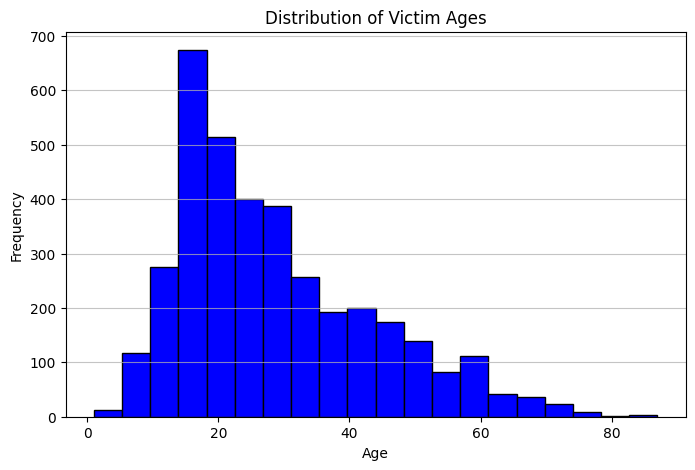

Missing Values: 0
Proportion of Male Victims as a %: 83.57963875205255

Type Value Counts:
 Type
Unprovoked    3043
Unknown        314
Provoked       297
Name: count, dtype: int64

Proportion of Unprovoked Attacks as a %: 83.28


In [29]:
#Problem 2
import pandas as pd
import matplotlib.pyplot as plt
shark_df = pd.read_excel('/content/GSAF5 (1).xls')

#Investiagte Data
print("shark_df.shape:")
print(shark_df.shape, '\n') #looking at size of data frame
shark_df.head(20)
print("Missing values:\n", shark_df.isna().sum())

#Drop Columns Not Containing Data
empty_cols = [c for c in shark_df.columns if shark_df[c].notna().sum() <= 2] #drop columns with 2 or less data entries
print("\nDropping:", empty_cols)
shark_df = shark_df.drop(columns=empty_cols)
print("\nNew df Shape", shark_df.shape) #check new size of data frame

#Clean Year Variable
shark_df['Year'].head(20) #needs to be stripped, dtype is float64
shark_df['Year'] = pd.to_numeric(shark_df['Year'], errors='coerce').astype('Int64') #converted dtype to Int64
shark_df = shark_df.dropna(subset=['Year']) #drop NA and none entries
shark_df['Year'] = shark_df['Year'].astype(int) #convert dtype to int
print("Missing Values:", shark_df['Year'].isna().sum()) #check missing values
shark_df['Year'].sort_values() #range from 0 to 2026
shark_df = shark_df[(shark_df['Year'] > 1400)] #removed years before 1400
shark_df['Year'].sort_values() #check new range of year

#Compare Number of Attacks Over the Years
shark_df = shark_df[(shark_df['Year'] > 1939)] #filter to focus on 1940 onwards
yearly_counts = shark_df.groupby('Year').size()
decade_means = yearly_counts.groupby(yearly_counts.index//10*10).mean().reset_index() #group yearly totals by decade
decade_means.columns = ['Decade', 'Mean Attacks Per Year']
decade_means['Mean Attacks Per Year'] = decade_means['Mean Attacks Per Year'].round(2) #round to 2 decimal places
print("\n", decade_means) #show mean number of attacks per decade

#Clean Age Variable
shark_df['Age'].head(20)
shark_df['Age'] = shark_df['Age'].astype(str).str.replace('+', '', regex=False) #remove +
shark_df['Age'] = shark_df['Age'].str.replace("'s", "", regex=False) #remove 's
shark_df['Age'] = pd.to_numeric(shark_df['Age'], errors='coerce') #convert to numeric
shark_df = shark_df.dropna(subset=['Age']) #dropped NaN values
shark_df['Age'].sort_values() #check cleaned age variable

#Make Histogram
plt.figure(figsize=(8, 5))
plt.hist(shark_df['Age'], bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Victim Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#Find Proportion of Male Victims
shark_df['Sex'] = shark_df['Sex'].astype(str).str.strip() #remove excess spaces
shark_df['Sex'] = shark_df['Sex'].astype(str).str.upper() #convert to uper case
print("Missing Values:", shark_df['Sex'].isna().sum()) #check missing values
male_proportion = (shark_df['Sex'] == 'M').sum()/len(shark_df) #calculate proportion of male victims
print("Proportion of Male Victims as a %:", male_proportion * 100) #print as a percentage

#Clean Type Variable & Calculate Proportion of Unprovoked Attacks
shark_df['Type'] = shark_df['Type'].astype(str).str.strip() #remove excess spaces
shark_df['Type'] = shark_df['Type'].astype(str).str.title() #convert to title case
def sort_type(val): # sort all entries into Provoked, Unprovoked, or Unknown
    if val == 'Provoked':
        return 'Provoked'
    elif val == 'Unprovoked':
        return 'Unprovoked'
    else:
        return 'Unknown'
shark_df['Type'] = shark_df['Type'].apply(sort_type)
unprovoked_proportion = (shark_df['Type'] == 'Unprovoked').sum() / len(shark_df) #calculate proportion of unprovoked attacks
print("\nType Value Counts:\n", shark_df['Type'].value_counts())
print("\nProportion of Unprovoked Attacks as a %:", round(unprovoked_proportion * 100, 2)) #round to 2 decimal places



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 605e553
- **AI tool and model used:** Chat GPT

### *Prompts used

1. I'm completing an assignment for my data science class in which I complete phase 1 on my own, and then use an AI model to revise my work. I'm working in colab and github and using python. Here are the instructions for each problem. I have also uploaded the attached data sets, and the reading assigned by my professor.

Help me understand 1) any mistakes I made/limitations in my work, 2) how to improve/fix them, and 3) why they need to be fixed.


Instructions:


My code:


2. Make a concise numbered list of everything that absolutely needs to be changed across both parts of problem 1 and problem 2.

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Q1.1 — Fix the dtype comment. pd.to_numeric() does not inherently “confirm int64”; just check and report the actual dtype after conversion.

2. Q1.1 — Add a written explanation of the cleaning choice. Explicitly say that $ and especially commas in values over 999 are formatting characters that must be removed before numeric conversion, and report that you end with 0 missing values.

3. Q1.2 — Replace astype(str) with astype('string'). Your current code temporarily turns real missing values into the literal string "nan". Using Pandas’ nullable string dtype preserves missingness correctly.

4. Q1.2 — Interpret the missingness, not just calculate it. State that about 76.19% of subject_injury values are missing and that this is a serious concern because so much injury information is unavailable.

5. Q1.2 — Analyze missingness by force_type. A raw cross-tab alone is not enough; calculate or discuss the proportion missing within each force type and explain that missingness varies substantially across categories, so it may bias later analysis.

6. Q2 — Do not define “empty column” as <= 2 nonmissing values. Drop truly empty columns with dropna(axis=1, how='all'), then separately inspect and justify dropping the stray Unnamed columns because they contain metadata/comments rather than real variables.

7. Q2 Year — Remove the arbitrary Year > 1400 rule. Clean the numeric year, describe the raw range/problems you see, then follow the assignment directly by filtering to 1940 onward.

8. Q2 Year — Improve the trend analysis. Use yearly counts and preferably a line plot to support the conclusion that recorded attacks generally increase over time. Do not treat the incomplete 2020s as directly comparable to complete decades.

9. Q2 Age — Do not permanently drop rows with missing/unclean Age from the main dataframe. This is the biggest issue in your code. Create an Age_clean variable and use .dropna() only on the temporary series used for the histogram.

10. Q2 Age — Explain what happens to messy age values. State that ranges, decades, multiple ages, and text descriptions are converted to missing rather than guessed into a single age.

11. Q2 Sex — Replace astype(str) with astype('string'). Otherwise real missing values become "nan" strings and your missing-value check becomes misleading.

12. Q2 Sex — Fix the denominator for the male proportion. Calculate it from the full post-1940 dataset, not the age-complete subset. If using only clearly coded M/F records, say so explicitly; that gives about 85.7% male.

13. Q2 Type — Apply Type cleaning to the full post-1940 dataset, not the age-filtered subset. Your current sequence inflates the unprovoked percentage because nearly 2,000 rows were already removed for Age.

14. Q2 Type — Correct the unprovoked result. Using the full post-1940 data, the proportion is about 74.6% unprovoked, not the roughly 83% produced after dropping rows with unclean Age.

15. Across all of Q2 — Preserve one master post-1940 dataframe. Clean each variable into separate columns such as Year_clean, Age_clean, Sex_clean, and Type_clean rather than repeatedly deleting observations. This is the structural fix that prevents most of the downstream errors.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / **modify** / reject | correctly converted to numeric dtype, added comment indicating conversion |
| 2 | Accept / **modify** / reject | checked dtpye after conversion, slightly adjusted comment |
| 3 | Accept / modify / **reject** | after further inquiry, issue is fixed later and does not affect final output |
| 4 | Accept / modify / **reject** | included in a textbox in github, but did not paste into chat gpt with my code, unnecessary |
| 5 | Accept / **modify** / reject | Included some analysis in textbox, but looked at data again and added aditional sentences |
| 6 | **Accept** / modify / reject | dropped unamed columns as they had no meaningful data, did not define them as empty |
| 7 | **Accept** / modify / reject | cleaned data by simpling filtering from 1940 onwards, not discarding misisng values |
| 8 | Accept / **modify** / reject | kept my chart showing mean number of attacks per decade, but also added line graph to strengthen conclusion that attacks are increasing over time |
| 9 | **Accept** / modify / reject | made appropiate changes as dropping values affects later analysis, labeled varaible clean_age|
| 10 | **Accept** / modify / reject | made comment, that messy age values were converted to missing |
| 11 | **Accept** / modify / reject | accepted as issue impacts missing values  |
| 12 | **Accept** / modify / reject | accepted as issue impacts value found for proportion of male victims |
| 13 | **Accept** / modify / reject | accepted so type analysis is only focused on attacks form 1940 onwards |
| 14 | Accept / **modify** / reject | changes in code address this issue, changed my response in corresponding text box |
| 15 | **Accept** / modify / reject | accepted to adjust all cleaning for attacks since 1940 |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [176]:
# Your Phase 2 solution to the problem goes here.


In [30]:
# Problem 1.1
import pandas as pd
airbnb_df = pd.read_csv('/content/airbnb_hw.csv')

#Investiagte Data
print("airbnb_df.shape:")
print(airbnb_df.shape, '\n') #looking at size of data frame
airbnb_df['Price'].head(20)
airbnb_df['Price'].sort_values() #need to strip data
airbnb_df['Price'].dtype #currently object data type, need to transform to integer

#Strip Data
airbnb_df['Price'] = airbnb_df['Price'].str.replace("$", "", regex=False)
airbnb_df['Price'] = airbnb_df['Price'].str.replace(",", "", regex=False) #stripped of $ and ,

#Convert Data
airbnb_df['Price'] = pd.to_numeric(airbnb_df['Price'], errors = "coerce") #convert to numeric
airbnb_df['Price'].dtype #confirm conversion of dtype to numeric

#Re-investigate Data
airbnb_df['Price'].head(20)
airbnb_df['Price'].sort_values()
print("Final Missing Values", airbnb_df['Price'].isna().sum()) #checking if data is cleaned sufficently

airbnb_df.shape:
(30478, 13) 

Final Missing Values 0


In [31]:
#Problem 1.2
import pandas as pd
police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

#Investiagte Data
print("police_df.shape:")
print(police_df.shape, '\n') #looking at size of data frame
police_df['subject_injury'].head(20)
print("Total Values",police_df['subject_injury'].value_counts(dropna=False)) #need to address NaN

#Clean Data
police_df['subject_injury'] = police_df['subject_injury'].astype('string') #convert to string
police_df['subject_injury'] = police_df['subject_injury'].str.strip() #remove excess spaces
police_df['subject_injury'] = police_df['subject_injury'].str.lower() #convert to lower case
police_df['subject_injury'].head(20) #check
police_df['subject_injury'] = police_df['subject_injury'].replace({
    'none': pd.NA,
    'na': pd.NA,
    'nan': pd.NA,
    '': pd.NA,
    'unknown': pd.NA})
police_df['subject_injury'] = police_df['subject_injury'].replace({
    'yes': 'Yes',
    'y': 'Yes',
    'no': 'No',
    'n': 'No'})

#Find Missing Values
police_df['subject_injury'].value_counts(dropna=False)
print("\nMissing values", police_df['subject_injury'].isna().sum())
print("Proportion of Missing values as a %:", round(police_df['subject_injury'].isna().mean()*100, 2))

#Cross Tabulate Data
pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury'],
    dropna=False)

police_df.shape:
(12925, 13) 

Total Values subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Missing values 9848
Proportion of Missing values as a %: 76.19


subject_injury,No,Yes,<NA>
force_type,,,
Baton,0,2,2
Bodily Force,1093,1286,7051
Chemical Irritant,131,41,1421
Firearm,2,0,0
Gun Point Display,33,44,27
Improvised Weapon,34,40,74
Less Lethal,0,0,87
Less Lethal Projectile,1,2,0
Maximal Restraint Technique,0,0,170


Approximately 76.2% of the values are missing (9,848 out of 12,925). Yes, this is definitely a concern because more than three quarters of the data points are missing. This leaves very few data points that can be used to determine whether a person was injured. The missing values are also not evenly distributed across force types, suggesting that missingness is related to the type of force used. For example, injury information is missing much more frequently for Chemical Irritant and Taser cases than for Gun Point Display cases. This could bias conclusions about the relationship between force type and injury

shark_df.shape:
(7117, 23) 

Missing values:
 Date                 0
Year                 2
Type                18
Country             50
State              487
Location           567
Activity           583
Name               218
Sex                578
Age               2994
Injury              36
Fatal Y/N          561
Time              3527
Species           3131
Source              20
pdf                318
href formula       323
href               321
Case Number        319
Case Number.1      320
original order     318
Unnamed: 21       7116
Unnamed: 22       7115
dtype: int64

Dropping: Unnamed: 21 Unnamed: 22

New df Shape: (7117, 21)
      Year  Attacks
0   1940.0       24
1   1941.0       27
2   1942.0       41
3   1943.0       28
4   1944.0       31
..     ...      ...
82  2022.0       98
83  2023.0      109
84  2024.0       52
85  2025.0       69
86  2026.0       53

[87 rows x 2 columns]

    Decade  Mean Attacks Per Year
0  1940.0                  28.30
1  1950.0           

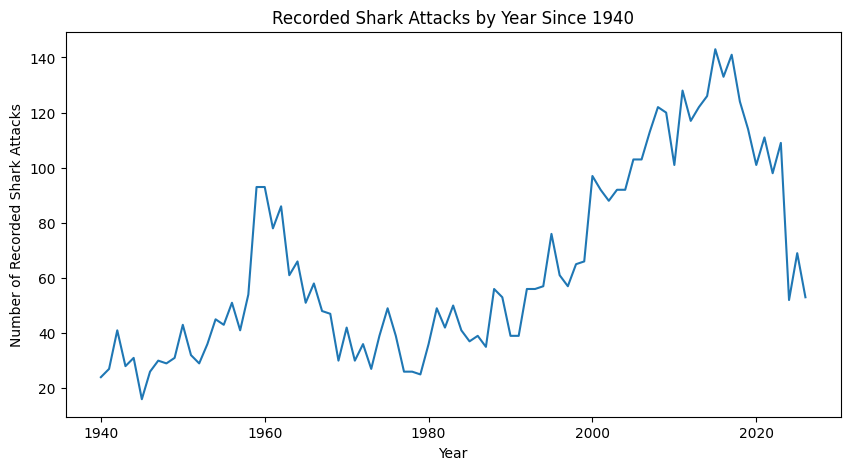

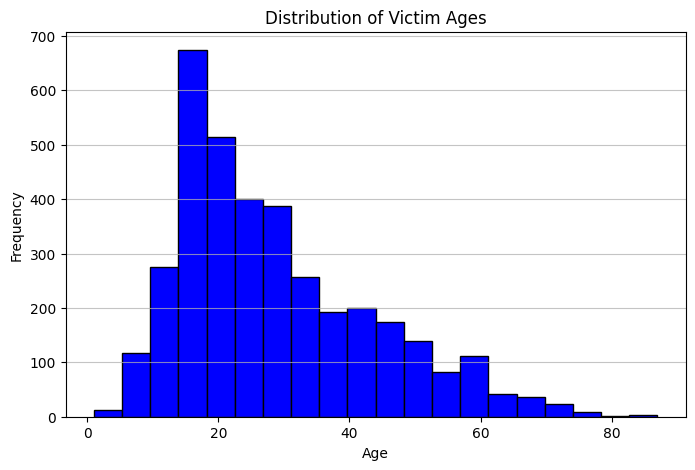

Missing Values: 451
Proportion of Male Victims as a %: 85.71707317073171

Type Value Counts:
 Type
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64

Proportion of Unprovoked Attacks as a %: 74.59


In [33]:
#Problem 2
import pandas as pd
import matplotlib.pyplot as plt
shark_df = pd.read_excel('/content/GSAF5 (1).xls')

#Investiagte Data
print("shark_df.shape:")
print(shark_df.shape, '\n') #looking at size of data frame
shark_df.head(20)
print("Missing values:\n", shark_df.isna().sum())

#Drop Columns Not Containing Data
shark_df = shark_df.dropna(axis=1, how='all') #drop columns that are completely empty
print("\nDropping:", 'Unnamed: 21', 'Unnamed: 22')
shark_df = shark_df.drop(
    columns=['Unnamed: 21', 'Unnamed: 22'])  #drop columns that have no meaningful data
print("\nNew df Shape:", shark_df.shape) #check size of new df

#Investiagte Year Variable
shark_df['Year'].head(20)
shark_df['Year'].sample(20) #contains year 0
shark_df['Year'].sort_values() #contains years NaN
shark1940_df = shark_df[shark_df['Year'] >= 1940].copy() #filter to focus on attacks from 1940 onwards

#Compare Number of Attacks Over the Years
yearly_attacks = (shark1940_df.groupby('Year').size().reset_index(name='Attacks')) #calculate amt of attacks each year
print(yearly_attacks)
yearly_counts = shark1940_df.groupby('Year').size()
decade_means = yearly_counts.groupby(yearly_counts.index//10*10).mean().reset_index() #group yearly totals by decade
decade_means.columns = ['Decade', 'Mean Attacks Per Year']
decade_means['Mean Attacks Per Year'] = decade_means['Mean Attacks Per Year'].round(2) #round to 2 decimal places
print("\n", decade_means) #show mean number of attacks per decade
plt.figure(figsize=(10, 5)) #make line graph
plt.plot(yearly_attacks['Year'], yearly_attacks['Attacks'])
plt.xlabel('Year')
plt.ylabel('Number of Recorded Shark Attacks')
plt.title('Recorded Shark Attacks by Year Since 1940')
plt.show()

#Clean Age Variable
shark1940_df['Age'].head(20)
shark1940_df['Age'] = shark1940_df['Age'].astype(str).str.replace('+', '', regex=False) #remove +
shark1940_df['Age'] = shark1940_df['Age'].str.replace("'s", "", regex=False) #remove 's
shark1940_df['Age'] = pd.to_numeric(shark1940_df['Age'], errors='coerce') #convert to numeric, convert ambigious entries to NaN
clean_age = shark1940_df['Age'].dropna() #drop NaN only for the age analysis
clean_age.sort_values() #check cleaned age variable

#Make Histogram
plt.figure(figsize=(8, 5))
plt.hist(clean_age, bins=20, color='blue', edgecolor='black')
plt.title('Distribution of Victim Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

#Find Proportion of Male Victims
shark1940_df['Sex'] = shark1940_df['Sex'].astype('string').str.strip() #remove excess spaces
shark1940_df['Sex'] = shark1940_df['Sex'].str.upper() #convert to uper case
print("Missing Values:", shark1940_df['Sex'].isna().sum()) #check missing values
known_sex = shark1940_df[shark1940_df['Sex'].isin(['M', 'F'])] #calculate proportion of known-sex victims who are male
male_proportion = (known_sex['Sex'] == 'M').sum() / len(known_sex)
print("Proportion of Male Victims as a %:", male_proportion * 100) #print proportion of male victims as a %

#Clean Type Variable & Calculate Proportion of Unprovoked Attacks
shark1940_df['Type'] = shark1940_df['Type'].astype(str).str.strip() #remove excess spaces
shark1940_df['Type'] = shark1940_df['Type'].astype(str).str.title() #convert to title case
def sort_type(val): # sort all entries into Provoked, Unprovoked, or Unknown
    if val == 'Provoked':
        return 'Provoked'
    elif val == 'Unprovoked':
        return 'Unprovoked'
    else:
        return 'Unknown'
shark1940_df['Type'] = shark1940_df['Type'].apply(sort_type)
unprovoked_proportion = ((shark1940_df['Type'] == 'Unprovoked').sum() / len(shark1940_df)) #calculate proportion of unprovoked attacks
print("\nType Value Counts:\n", shark1940_df['Type'].value_counts())
print("\nProportion of Unprovoked Attacks as a %:", round(unprovoked_proportion * 100, 2)) #round to 2 decimal places

### *Reflection on AI assistance
In your own words without generative AI.

Overall, I found this method to be relatively efficient and useful. I think that a detailed and specific prompt is important to getting good feedback. I found the initial feedback very overwhelming and difficult to understand. I used the concise and numbered list as well as periodic prompts for additional clarification in order to understand why something needed to be fixed. Initially, Chat GPT prompted me to fix far more, so narrowing it down to what was absolutely necessary removed a lot of the suggestions that I would have ignored. There were some that I ignored simply because it was asking me to include information which was simply in a text box that I had not included in my prompt. The main improvements I made were on problem 2. I filtered and separated the attacks beyond 1940, strengthened the analysis of shark attacks increasing over time by adding a line graph, changed the way I cleaned variables to not completely drop missing values, fixed the calculation for male victims, and made the post-1940 restriction consistent across the shark analyses. I verified each suggestion by checking my code, consulting the class slides, and researching explanations when needed. One remaining concern is whether Chat GPT correctly interpreted the assignment instructions as they were intended. I found myself going back after reading each suggestion to ensure that it was what the instructions actually intended.